In [1]:
%pip install timm faiss-cpu scikit-learn nibabel gradio torch torchvision torchaudio scipy grad-cam opencv-python --quiet

import cv2
import faiss
import gc
import glob
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os
import pandas as pd
import pickle
import random
import re
import time
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as cp
import torchvision.models as models
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import warnings

from IPython.display import clear_output
from itertools import chain
from pathlib import Path
from PIL import Image
from scipy.ndimage import zoom as scipy_zoom
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
from tqdm.auto import tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import warnings
import random
import numpy as np
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import timm

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURACIÓN Y REPRODUCIBILIDAD
# ==========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_GPUS = torch.cuda.device_count()
print(f"Dispositivo: {DEVICE}  |  GPUs: {N_GPUS}")

if DEVICE == "cuda":
    for i in range(N_GPUS):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  |  VRAM: {p.total_memory/1e9:.1f} GB")

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ==========================================
# 2. RUTAS Y METADATOS
# ==========================================
# Paths ABSOLUTOS — robustos ante cambio de CWD 
PROJECT_ROOT = "/proyecto-2-de-mierda/proyecto-2-de-mierda"
BASE_DATA    = os.path.join(PROJECT_ROOT, "DATA")
MOE_DIR      = os.path.join(PROJECT_ROOT, "moe")

PATHS = {
    "isic":       os.path.join(BASE_DATA, "isic"),
    "luna":       os.path.join(BASE_DATA, "luna"),
    "rodilla":    os.path.join(BASE_DATA, "rodilla"),
    "pancreatic": os.path.join(BASE_DATA, "pancreatic"),
    "nih":        os.path.join(BASE_DATA, "nih"),
    "plots":      os.path.join(BASE_DATA, "plots"),
    "embeddings": os.path.join(BASE_DATA, "embeddings"),
    "tokens":     os.path.join(BASE_DATA, "tokens"),
    "moe":        MOE_DIR,
}

for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

ISIC_IMG_DIR    = os.path.join(PATHS["isic"],       "ISIC_2019_Training_Input")
LUNA_NPY_DIR    = os.path.join(PATHS["luna"],       "preprocessed_npy_v2", "preprocessed_npy_v2")
PANCREATIC_DIR  = os.path.join(PATHS["pancreatic"], "tensor_cache")
RODILLA_DIR     = os.path.join(PATHS["rodilla"],    "processed")
NIH_TENSOR_DIR  = os.path.join(PATHS["nih"],        "tensores")

WEIGHTS = {
    "isic":       os.path.join(PATHS["isic"],       "experto_isic_best.pt"),
    "rodilla":    os.path.join(PATHS["rodilla"],    "experto_rodilla_best.pth"),
    "luna":       os.path.join(PATHS["luna"],       "experto_luna_best.pth"),
    "pancreatic": os.path.join(PATHS["pancreatic"], "experto_pancreatic_best.pt"),
    "nih":        os.path.join(PATHS["nih"],        "best_nih_v7.pth"),   
}

CFG = {
    "img_size_2d":       224,
    "img_size_3d":       64,
    "batch_size":        8,
    "accum_steps":       4,
    "lr_router":         1e-4,
    "lr_experts":        1e-5,
    "epochs_moe":        40,
    "n_experts":         5,
    "d_model":           192,
    "alpha_aux":         0.20,  # subido a 0.20 para forzar balance < 1.30va
    "knn_k":             5,
    "balance_threshold": 1.30,
}

DATASET_TO_EXPERT = {
    "isic":       0,   # Exp1
    "rodilla":    1,   # Exp2
    "nih":        2,   # Exp3
    "luna":       3,   # Exp4 (3D)
    "pancreatic": 4,   # Exp5 (3D)
}

EXPERT_META = {
    0: {"name": "Exp1 — ISIC 2019",         "n_classes": 8,  "task": "multiclass",  "key": "isic",       "dim": "2D"},
    1: {"name": "Exp2 — Osteoarthritis",     "n_classes": 3,  "task": "multiclass",  "key": "rodilla",    "dim": "2D"},
    2: {"name": "Exp3 — NIH ChestX-ray14",   "n_classes": 7,  "task": "multilabel",  "key": "nih",        "dim": "2D"},
    3: {"name": "Exp4 — LUNA16 CT 3D",       "n_classes": 2,  "task": "binary",      "key": "luna",       "dim": "3D"},
    4: {"name": "Exp5 — Pancreatic CT 3D",   "n_classes": 2,  "task": "binary",      "key": "pancreatic", "dim": "3D"},
}

for k, p in[("BASE_DATA", BASE_DATA), ("ISIC", ISIC_IMG_DIR), ("LUNA", LUNA_NPY_DIR),
             ("PANCREATIC", PANCREATIC_DIR), ("RODILLA", RODILLA_DIR), ("NIH", NIH_TENSOR_DIR)]:
    print(f"n_experts={CFG['n_experts']}  |  Expertos 3D: Exp4 (LUNA16), Exp5 (Pancreatic)")


# ==========================================
# A. PREPROCESADOR ADAPTATIVO
# ==========================================
class AdaptivePreprocessor(nn.Module):
    _IMAGENET_MEAN = [0.485, 0.456, 0.406]
    _IMAGENET_STD  =[0.229, 0.224, 0.225]

    # Rangos HU por modalidad 3D
    HU_LUNA       = (-1200, 600)   
    HU_PANCREATIC = (-1000, 400)   

    def __init__(self, size_2d=224, size_3d=64):
        super().__init__()
        self.size_2d = size_2d
        self.size_3d = size_3d
        self.register_buffer(
            "imagenet_mean",
            torch.tensor(self._IMAGENET_MEAN, dtype=torch.float32).view(1, 3, 1, 1),
        )
        self.register_buffer(
            "imagenet_std",
            torch.tensor(self._IMAGENET_STD, dtype=torch.float32).view(1, 3, 1, 1),
        )

    def _to_rgb(self, x):
        return x.repeat(1, 3, 1, 1) if x.shape[1] == 1 else x

    def _resize_2d(self, x):
        return F.interpolate(x.float(), size=(self.size_2d, self.size_2d),
                             mode="bilinear", align_corners=False)

    def _normalize_2d(self, x):
        return (x - self.imagenet_mean) / self.imagenet_std

    @staticmethod
    def _apply_clahe(x: torch.Tensor) -> torch.Tensor:
        out = x.clone()
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        for b in range(x.shape[0]):
            img_np = (x[b].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            if img_np.shape[2] == 1:
                img_np = clahe.apply(img_np[:, :, 0])[:, :, np.newaxis]
            else:
                ycrcb = cv2.cvtColor(img_np, cv2.COLOR_RGB2YCrCb)
                ycrcb[:, :, 0] = clahe.apply(ycrcb[:, :, 0])
                img_np = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)
            out[b] = torch.from_numpy(img_np.astype(np.float32) / 255.0).permute(2, 0, 1)
        return out

    @staticmethod
    def _isic_augment(x: torch.Tensor) -> torch.Tensor:
        out =[]
        for img in x:
            if random.random() > 0.5: img = TF.hflip(img)
            if random.random() > 0.5: img = TF.vflip(img)
            img = (img * random.uniform(0.8, 1.2)).clamp(0, 1)
            out.append(img)
        return torch.stack(out)

    @staticmethod
    def _preprocess_3d_torch(x: torch.Tensor, hu_min: int, hu_max: int, size_3d: int) -> torch.Tensor:
        hu_range = float(hu_max - hu_min)
        x = torch.clamp(x.float(), hu_min, hu_max)
        x = (x - hu_min) / hu_range
        x = F.interpolate(x, size=(size_3d,) * 3, mode="trilinear", align_corners=False)
        return x.clamp(0.0, 1.0)

    def forward(self, x: torch.Tensor, mode: str = None) -> torch.Tensor:
        if x.ndim == 5 or mode in ("luna", "pancreatic", "3d"):
            if mode == "luna":
                hu_min, hu_max = self.HU_LUNA
            else:
                hu_min, hu_max = self.HU_PANCREATIC
            return self._preprocess_3d_torch(x, hu_min, hu_max, self.size_3d)

        # 2D pipeline
        x = x.float()
        if x.max() > 2.0:
            x = x / 255.0
        x = self._to_rgb(x)
        if mode == "knee":
            x = self._apply_clahe(x)
        x = self._resize_2d(x)
        if mode == "isic":
            x = self._isic_augment(x)
        return self._normalize_2d(x)

# ==========================================
# B. BACKBONE COMPARTIDO
# ==========================================
class SharedViTBackbone(nn.Module):
    def __init__(self, model_name="vit_tiny_patch16_224", pretrained=True, freeze=True):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool="token")
        self.d_model = self.vit.embed_dim   # 192
        
        self.register_buffer("imagenet_mean",
            torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("imagenet_std",
            torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1))
            
        if freeze:
            for p in self.vit.parameters():
                p.requires_grad_(False)

    def _volume_to_slice(self, x: torch.Tensor) -> torch.Tensor:
        mid = x.shape[2] // 2
        slc = x[:, :, mid, :, :]                              
        slc = slc.repeat(1, 3, 1, 1) if slc.shape[1] == 1 else slc
        slc = F.interpolate(slc, size=(224, 224), mode="bilinear", align_corners=False)
        slc = (slc - self.imagenet_mean) / self.imagenet_std 
        return slc

    def _to_2d(self, x: torch.Tensor) -> torch.Tensor:
        return self._volume_to_slice(x) if x.ndim == 5 else x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.vit(self._to_2d(x))

# ==========================================
# C. TOKEN GENERATOR
# ==========================================
class TokenGenerator:
    def __init__(self, backbone: SharedViTBackbone, save_dir: str, token_mode: str = "cls"):
        self.backbone   = backbone
        self.save_dir   = save_dir
        self.token_mode = token_mode
        self.d_model    = backbone.d_model
        
        assert token_mode in ("cls", "patch", "hybrid"), \
            f"token_mode debe ser 'cls', 'patch' o 'hybrid'. Got: {token_mode}"
            
        os.makedirs(save_dir, exist_ok=True)

    def _get_all_tokens(self, x: torch.Tensor):
        vit_model = self.backbone.vit if hasattr(self.backbone, "vit") else self.backbone.backbone.vit
        x_to_2d   = self.backbone._to_2d if hasattr(self.backbone, "_to_2d") else self.backbone.backbone._to_2d
        x_2d = x_to_2d(x)
        
        with torch.no_grad():
            all_tok = vit_model.forward_features(x_2d)  
            
        cls   = all_tok[:, 0, :]    
        patch = all_tok[:, 1:, :]   
        return cls, patch

    def extract_and_save(self, datasets_dict: dict, split_name: str, batch_size: int = 16, force_recompute: bool = False) -> tuple:
        z_cls_path = os.path.join(self.save_dir, f"Z_{split_name}_cls.npy")
        z_tok_path = os.path.join(self.save_dir, f"Z_{split_name}_tokens.npy")
        y_path     = os.path.join(self.save_dir, f"y_{split_name}.npy")

        if all(os.path.exists(p) for p in [z_cls_path, z_tok_path, y_path]) and not force_recompute:
            print(f"  [{split_name}] Cargando tokens desde disco...")
            Z_cls    = np.load(z_cls_path)
            Z_tokens = np.load(z_tok_path)
            y        = np.load(y_path)
            print(f"  Z_cls: {Z_cls.shape}  Z_tokens: {Z_tokens.shape}  y: {y.shape}")
            return Z_cls, Z_tokens, y

        self.backbone.eval()
        all_cls, all_tok, all_y = [],[],[]

        for name, ds in datasets_dict.items():
            expert_id = DATASET_TO_EXPERT[name]
            loader    = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
            print(f"[{split_name}][{name}] expert_id={expert_id}  n={len(ds)}")

            for bi, batch in enumerate(loader):
                imgs = batch[0].to(DEVICE)

                with torch.no_grad():
                    cls_tok, patch_tok = self._get_all_tokens(imgs)

                all_cls.append(cls_tok.cpu().numpy())

                if self.token_mode == "cls":
                    tok_np = cls_tok.unsqueeze(1).cpu().numpy()   
                elif self.token_mode == "patch":
                    tok_np = patch_tok.cpu().numpy()              
                else:  
                    hybrid = torch.cat([cls_tok.unsqueeze(1), patch_tok], dim=1)
                    tok_np = hybrid.cpu().numpy()                 

                all_tok.append(tok_np)
                all_y.append(np.full(len(imgs), expert_id, dtype=np.int64))

                if (bi + 1) % 50 == 0:
                    print(f"    {bi+1}/{len(loader)} batches")

        Z_cls    = np.concatenate(all_cls).astype(np.float32)
        Z_tokens = np.concatenate(all_tok).astype(np.float32)
        y        = np.concatenate(all_y).astype(np.int64)

        np.save(z_cls_path, Z_cls)
        np.save(z_tok_path, Z_tokens)
        np.save(y_path,     y)

        dist = dict(zip(*np.unique(y, return_counts=True)))
        print(f"  Guardado → Z_cls:{Z_cls.shape} Z_tokens:{Z_tokens.shape} y:{y.shape}")
        print(f"  Distribución expertos: {dist}")
        
        assert len(np.unique(y)) > 1, \
            "ERROR: solo 1 clase en y — verifica DATASET_TO_EXPERT"
            
        return Z_cls, Z_tokens, y

# ==========================================
# D. PIPELINE COMPLETO
# ==========================================
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Instanciar Preprocessor 
preprocessor = AdaptivePreprocessor(
    size_2d=CFG["img_size_2d"],
    size_3d=CFG["img_size_3d"],
).to(DEVICE)

# Wrapper y Backbone
class BackboneWrapper(nn.Module):
    def __init__(self, backbone, output_device):
        super().__init__()
        self.backbone      = backbone
        self.output_device = output_device
        self.d_model       = backbone.d_model
        
    def _to_2d(self, x):
        return self.backbone._to_2d(x.to(next(self.backbone.parameters()).device))
        
    def forward(self, x):
        return self.backbone(x.to(next(self.backbone.parameters()).device)).to(self.output_device)

def load_backbone_safe(device_target):
    try:
        m = SharedViTBackbone(pretrained=True, freeze=True).to(device_target)
        print(f" Backbone en {device_target}")
        return m, device_target
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache()
            m = SharedViTBackbone(pretrained=True, freeze=True).to("cpu")
            print("  OOM GPU — backbone en CPU, wrapper activo")
            return BackboneWrapper(m, device_target), "cpu"
        raise

backbone, BACKBONE_DEVICE = load_backbone_safe(DEVICE)
CFG["d_model"] = backbone.d_model if hasattr(backbone, "d_model") else backbone.backbone.d_model

# Instanciar TokenGenerator 
token_gen = TokenGenerator(
    backbone   = backbone,
    save_dir   = PATHS["tokens"],
    token_mode = "cls",   
)

# Smoke-test 
with torch.no_grad():
    # 2D RGB
    x2d = torch.randint(0, 256, (2, 3, 512, 512), dtype=torch.float32).to(DEVICE)
    p2d = preprocessor(x2d)
    z2d = backbone(p2d)

    # 2D grayscale rodilla (CLAHE)
    xkn = torch.randint(0, 256, (2, 1, 400, 400), dtype=torch.float32).to(DEVICE)
    pkn = preprocessor(xkn, mode="knee")
    zkn = backbone(pkn)

    # 3D LUNA16 (-1200 / 600)
    xl  = torch.randint(-1200, 600, (2, 1, 128, 256, 256), dtype=torch.float32).to(DEVICE)
    pl  = preprocessor(xl, mode="luna")
    zl  = backbone(pl)

    # 3D Pancreatic (-1000 / 400)
    xp  = torch.randint(-1000, 400, (2, 1, 96, 192, 192), dtype=torch.float32).to(DEVICE)
    pp  = preprocessor(xp, mode="pancreatic")
    zp  = backbone(pp)

    # TokenGenerator — CLS token + patch tokens
    cls_t, patch_t = token_gen._get_all_tokens(p2d)
    print("Smoke-test ejecutado con éxito.")

Dispositivo: cuda  |  GPUs: 1
  GPU 0: NVIDIA GeForce RTX 4090  |  VRAM: 25.3 GB
n_experts=5  |  Expertos 3D: Exp4 (LUNA16), Exp5 (Pancreatic)
n_experts=5  |  Expertos 3D: Exp4 (LUNA16), Exp5 (Pancreatic)
n_experts=5  |  Expertos 3D: Exp4 (LUNA16), Exp5 (Pancreatic)
n_experts=5  |  Expertos 3D: Exp4 (LUNA16), Exp5 (Pancreatic)
n_experts=5  |  Expertos 3D: Exp4 (LUNA16), Exp5 (Pancreatic)
n_experts=5  |  Expertos 3D: Exp4 (LUNA16), Exp5 (Pancreatic)
 Backbone en cuda
Smoke-test ejecutado con éxito.


In [3]:
class RouterAttentionHeatmap:
    
    def __init__(self, backbone_model):
        self.backbone     = backbone_model
        self.attn_weights = None
        self._hook        = None
        self._register_hook()

    def _register_hook(self):
        last_block = self.backbone.vit.blocks[-1]
        def hook_fn(module, inp, out):
            self.attn_weights = out.detach().cpu()
        self._hook = last_block.attn.attn_drop.register_forward_hook(hook_fn)

    def remove_hook(self):
        if self._hook: self._hook.remove()

    @torch.no_grad()
    def get_heatmap(self, img_tensor, img_pil_original):
        self.attn_weights = None
        self.backbone.eval()
        _ = self.backbone(img_tensor)
        if self.attn_weights is None: return None
        attn     = self.attn_weights[0]
        cls_attn = attn[:, 0, 1:].mean(dim=0)
        grid     = int(cls_attn.shape[0] ** 0.5)
        cls_attn = cls_attn.reshape(grid, grid).numpy()
        cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
        w, h     = img_pil_original.size
        hm       = cv2.resize(cls_attn, (w, h), interpolation=cv2.INTER_CUBIC)
        cmap     = cm.get_cmap("jet")
        hm_rgb   = (cmap(hm)[:,:,:3] * 255).astype("uint8")
        img_np   = np.array(img_pil_original.convert("RGB"))
        return (0.55 * img_np + 0.45 * hm_rgb).astype("uint8")

try:
    heatmap_extractor = RouterAttentionHeatmap(backbone)
except Exception as e:
    heatmap_extractor = None
    print(f"WARN heatmap no disponible: {e}")

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm_2d = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(0.2, 0.2, 0.2, 0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tfm_2d = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ISICDataset(Dataset):
    EXPERT_ID = DATASET_TO_EXPERT["isic"]
    def __init__(self, df, transform, img_dir):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.img_dir   = Path(img_dir)
        self.cache     = {p.name: p for p in self.img_dir.glob("*.jpg")}
        print(f"  ISICDataset: {len(self.df)} imgs | cache={len(self.cache)}")
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        name = row["image"] + ".jpg"
        path = self.cache.get(name)
        if path is None:
            found = list(self.img_dir.rglob(name))
            if not found: raise FileNotFoundError(f"{name} no encontrado")
            path = found[0]; self.cache[name] = path
        img = Image.open(path).convert("RGB")
        return self.transform(img), int(row["label_idx"]), self.EXPERT_ID

class OADataset(Dataset):
    EXPERT_ID = DATASET_TO_EXPERT["rodilla"]
    def __init__(self, root, split="train", transform=None):
        self.transform = transform or val_tfm_2d
        split_dir      = os.path.join(root, split)
        self.samples   = []
        for kl in ["0", "1", "2"]:
            kl_dir = os.path.join(split_dir, kl)
            if not os.path.isdir(kl_dir): continue
            for f in os.listdir(kl_dir):
                if f.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(kl_dir, f), int(kl)))
        print(f"  OADataset [{split}]: {len(self.samples)} imgs")
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label, self.EXPERT_ID

class LUNADataset(Dataset):
    EXPERT_ID = DATASET_TO_EXPERT["luna"]
    def __init__(self, npy_root, split="train", size=64):
        self.size    = size
        self.samples = []
        npy_root     = Path(npy_root)
        all_files    = []
        for subset_dir in sorted(npy_root.glob("subset*")):
            for f in subset_dir.glob("*_pixels.npy"):
                all_files.append(f)
        if not all_files:
            print(f"  WARN LUNADataset: sin archivos *_pixels.npy en {npy_root}")
            return
        def get_label(p):
            parts = p.stem.replace("_pixels","").split("_")
            try: return min(int(parts[-1]), 1)
            except ValueError: return 0
        labeled = [(f, get_label(f)) for f in all_files]
        random.Random(SEED).shuffle(labeled)
        cut = int(0.8 * len(labeled))
        self.samples = labeled[:cut] if split == "train" else labeled[cut:]
        print(f"  LUNADataset [{split}]: {len(self.samples)} nodulos (HU-1200/600, preprocesado)")
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        vol = np.load(path).astype(np.float32)
        if vol.ndim == 3: vol = vol[np.newaxis, ...]
        return torch.from_numpy(vol), label, self.EXPERT_ID

class PancreaticDataset(Dataset):
    
    EXPERT_ID = DATASET_TO_EXPERT["pancreatic"]
    def __init__(self, tensor_dir, split="train", size=64):
        self.size    = size
        self.samples = []
        tensor_dir   = Path(tensor_dir)
        all_files    = sorted(tensor_dir.glob("*.pt"))
        if not all_files:
            print(f"  WARN PancreaticDataset: sin .pt en {tensor_dir}")
            return
        patients = {}
        for f in all_files:
            pid = f.stem.split("_")[0]
            patients.setdefault(pid, []).append(f)
        plist = sorted(patients.keys())
        random.Random(SEED).shuffle(plist)
        cut        = int(0.8 * len(plist))
        split_pids = plist[:cut] if split == "train" else plist[cut:]
        for pid in split_pids:
            label = 1 if pid.startswith("1") else 0
            for f in patients[pid]:
                self.samples.append((f, label))
        print(f"  PancreaticDataset [{split}]: {len(self.samples)} slices (HU-1000/400, preprocesado)")
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        vol = torch.load(path, map_location="cpu", weights_only=True)
        if isinstance(vol, dict):
            vol = vol.get("data", list(vol.values())[0])
        vol = vol.float()
        # Asegurar shape (1, D, H, W) sin doble interpolación (CORRECCIÓN)
        if vol.dim() == 3:
            vol = vol.unsqueeze(0)
        elif vol.dim() == 4 and vol.shape[0] != 1:
            vol = vol[:1]
        # Solo interpolar si el tamaño no es el esperado (safety check)
        if vol.shape[-1] != self.size:
            vol = F.interpolate(vol.unsqueeze(0), size=(self.size,)*3,
                                mode="trilinear", align_corners=False).squeeze(0)
        return vol, label, self.EXPERT_ID

class FixedSizeDataset(Dataset):
    
    def __init__(self, base, n=1000):
        self.base = base
        self.n    = int(n)
        L = len(base)
        if L >= n:
            self.idx = np.arange(n, dtype=np.int64)
        else:
            reps     = (n // L) + 1
            self.idx = np.tile(np.arange(L), reps)[:n]
    def __len__(self):   return self.n
    def __getitem__(self, i): return self.base[int(self.idx[i])]

TRAIN_SAMPLES_PER_EXPERT = 1000   # fija el balance de datos por experto

print("="*60)
print("Cargando datasets...")
print("="*60)
datasets_train, datasets_val = {}, {}

try:
    gt = pd.read_csv(os.path.join(PATHS["isic"], "ISIC_2019_Training_GroundTruth.csv"))
    if "UNK" in gt.columns:
        n_before = len(gt)
        gt = gt[gt["UNK"] == 0].drop(columns=["UNK"]).reset_index(drop=True)
        print(f"  ISIC: filtradas {n_before-len(gt)} muestras UNK → {len(gt)} ejemplos en 8 clases")
    label_cols      = [c for c in gt.columns if c != "image"]
    gt["label"]     = gt[label_cols].idxmax(axis=1)
    ISIC_CLASSES    = sorted(gt["label"].unique())
    C2I             = {c: i for i, c in enumerate(ISIC_CLASSES)}
    gt["label_idx"] = gt["label"].map(C2I)
    tr_df, vl_df    = train_test_split(gt, test_size=0.2, random_state=SEED,
                                       stratify=gt["label"])
    datasets_train["isic"] = ISICDataset(tr_df, train_tfm_2d, ISIC_IMG_DIR)
    datasets_val["isic"]   = ISICDataset(vl_df, val_tfm_2d,   ISIC_IMG_DIR)
    print(f"  OK ISIC")
except Exception as e:
    print(f"  FAIL ISIC: {e}")

try:
    datasets_train["rodilla"] = OADataset(RODILLA_DIR, "train", train_tfm_2d)
    datasets_val["rodilla"]   = OADataset(RODILLA_DIR, "val",   val_tfm_2d)
    print(f"  OK Rodilla")
except Exception as e:
    print(f"  FAIL Rodilla: {e}")

try:
    datasets_train["luna"] = LUNADataset(LUNA_NPY_DIR, "train", CFG["img_size_3d"])
    datasets_val["luna"]   = LUNADataset(LUNA_NPY_DIR, "val",   CFG["img_size_3d"])
    print(f"  OK LUNA")
except Exception as e:
    print(f"  FAIL LUNA: {e}")

try:
    datasets_train["pancreatic"] = PancreaticDataset(PANCREATIC_DIR, "train", CFG["img_size_3d"])
    datasets_val["pancreatic"]   = PancreaticDataset(PANCREATIC_DIR, "val",   CFG["img_size_3d"])
    print(f"  OK Pancreatic")
except Exception as e:
    print(f"  FAIL Pancreatic: {e}")

# ---- NIH (v5: inline, sin dependencia de train_nih_v7.py) ----
NIH_TENSOR_DIR = "/proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/nih/tensores"
NIH_CLASSES = ["No Finding", "Infiltration", "Effusion", "Atelectasis",
                "Nodule", "Mass", "Pneumothorax"]
_NIH_NO_FINDING_FRAC = 0.30

def _nih_indices_and_labels(split, subsample_nf=False):
    y_full = np.load(os.path.join(NIH_TENSOR_DIR, f"y_{split}.npy"))
    y_7    = y_full[:, :7]
    valid  = y_7.sum(axis=1) > 0
    idx    = np.where(valid)[0]
    if subsample_nf:
        y_valid = y_7[idx]
        is_nf   = (y_valid[:, 0] == 1.0) & (y_valid.sum(axis=1) == 1.0)
        nf_idx  = np.where(is_nf)[0]
        other   = np.where(~is_nf)[0]
        rng     = np.random.RandomState(444)
        keep    = rng.choice(nf_idx, int(len(nf_idx) * _NIH_NO_FINDING_FRAC), replace=False)
        final   = np.concatenate([other, keep])
        rng.shuffle(final)
        idx = idx[final]
    return idx, y_7

class NihMoEDataset(Dataset):
    
    EXPERT_ID = DATASET_TO_EXPERT["nih"]
    IMG_SIZE  = 224

    def __init__(self, X_mmap, Y, indices, train_mode=True):
        self.X   = X_mmap
        self.Y   = torch.tensor(Y[indices], dtype=torch.float32)
        self.idx = indices
        if train_mode:
            self.tfm = T.Compose([
                T.Resize((self.IMG_SIZE, self.IMG_SIZE), antialias=True),
                T.RandomHorizontalFlip(p=0.4),
                T.RandomAffine(degrees=6, translate=(0.05, 0.05), scale=(0.95, 1.05)),
                T.ColorJitter(brightness=0.15, contrast=0.15),
                T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        else:
            self.tfm = T.Compose([
                T.Resize((self.IMG_SIZE, self.IMG_SIZE), antialias=True),
                T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])

    def __len__(self): return len(self.idx)

    def __getitem__(self, i):
        real = int(self.idx[i])
        img  = self.X[real].reshape(384, 384).astype(np.float32) / 255.0
        img  = np.stack([img, img, img], axis=0)
        img  = torch.from_numpy(img)
        img  = self.tfm(img)
        return img, self.Y[i], self.EXPERT_ID

if not os.path.isdir(NIH_TENSOR_DIR):
    raise FileNotFoundError(f"NIH_TENSOR_DIR no existe: {NIH_TENSOR_DIR}")

nih_idx_tr, nih_Y_tr = _nih_indices_and_labels("train", subsample_nf=True)
nih_idx_vl, nih_Y_vl = _nih_indices_and_labels("val",   subsample_nf=False)
nih_X_tr = np.load(os.path.join(NIH_TENSOR_DIR, "X_train.npy"), mmap_mode="r")
nih_X_vl = np.load(os.path.join(NIH_TENSOR_DIR, "X_val.npy"),   mmap_mode="r")

datasets_train["nih"] = NihMoEDataset(nih_X_tr, nih_Y_tr, nih_idx_tr, train_mode=True)
datasets_val["nih"]   = NihMoEDataset(nih_X_vl, nih_Y_vl, nih_idx_vl, train_mode=False)
print(f"  OK NIH: train={len(datasets_train['nih'])}  val={len(datasets_val['nih'])}")
print(f"  NIH classes: {NIH_CLASSES}  (expert_id={DATASET_TO_EXPERT['nih']})")

#  BALANCEO DURO: cada dataset train con TRAIN_SAMPLES_PER_EXPERT muestras 
print(f"\nAplicando FixedSizeDataset(n={TRAIN_SAMPLES_PER_EXPERT}) a train...")
for k in list(datasets_train.keys()):
    base = datasets_train[k]
    L    = len(base)
    datasets_train[k] = FixedSizeDataset(base, n=TRAIN_SAMPLES_PER_EXPERT)
    print(f"  {k:<12}: {L:>6} → {len(datasets_train[k]):>6} muestras")

print(f"\nDatasets train: {list(datasets_train.keys())}")
print(f"Datasets val:   {list(datasets_val.keys())}")

class NIHDataset(Dataset):
    
    EXPERT_ID = DATASET_TO_EXPERT["nih"]
    LABELS    = ["Atelectasis","Cardiomegaly","Consolidation","Edema",
                 "Effusion","Emphysema","Fibrosis","Hernia",
                 "Infiltration","Mass","Nodule","Pleural_Thickening",
                 "Pneumonia","Pneumothorax"]
    N_CLASSES = 14

    def __init__(self, root, split="train", transform=None, max_samples=None):
        self.transform  = transform or val_tfm_2d
        self.img_dir    = Path(root) / "images"
        csv_path        = Path(root) / f"{split}.csv"
        if not csv_path.exists():
            # fallback: Data_Entry_2017.csv + split by patient
            csv_path = Path(root) / "Data_Entry_2017.csv"
        df              = pd.read_csv(csv_path)
        if "Image Index" in df.columns:
            df = df.rename(columns={"Image Index": "image", "Finding Labels": "labels"})
        if max_samples:
            df = df.head(max_samples)
        self.samples    = df.reset_index(drop=True)
        print(f"  NIHDataset [{split}]: {len(self.samples)} imgs")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        row     = self.samples.iloc[idx]
        img_path = self.img_dir / row["image"]
        if not img_path.exists():
            found = list((self.img_dir.parent).rglob(row["image"]))
            img_path = found[0] if found else img_path
        img     = Image.open(img_path).convert("RGB")
        if self.transform: img = self.transform(img)
        # multilabel vector de 14 posiciones
        label_str = row.get("labels", "No Finding")
        label_vec = torch.zeros(self.N_CLASSES, dtype=torch.float32)
        for lbl in str(label_str).split("|"):
            lbl = lbl.strip()
            if lbl in self.LABELS:
                label_vec[self.LABELS.index(lbl)] = 1.0
        return img, label_vec, self.EXPERT_ID

Cargando datasets...
  ISIC: filtradas 0 muestras UNK → 25331 ejemplos en 8 clases
  ISICDataset: 20264 imgs | cache=25331
  ISICDataset: 5067 imgs | cache=25331
  OK ISIC
  OADataset [train]: 2640 imgs
  OADataset [val]: 660 imgs
  OK Rodilla
  LUNADataset [train]: 710 nodulos (HU-1200/600, preprocesado)
  LUNADataset [val]: 178 nodulos (HU-1200/600, preprocesado)
  OK LUNA
  PancreaticDataset [train]: 445 slices (HU-1000/400, preprocesado)
  PancreaticDataset [val]: 110 slices (HU-1000/400, preprocesado)
  OK Pancreatic
  OK NIH: train=39607  val=12312
  NIH classes: ['No Finding', 'Infiltration', 'Effusion', 'Atelectasis', 'Nodule', 'Mass', 'Pneumothorax']  (expert_id=2)

Aplicando FixedSizeDataset(n=1000) a train...
  isic        :  20264 →   1000 muestras
  rodilla     :   2640 →   1000 muestras
  luna        :    710 →   1000 muestras
  pancreatic  :    445 →   1000 muestras
  nih         :  39607 →   1000 muestras

Datasets train: ['isic', 'rodilla', 'luna', 'pancreatic', 'nih']

In [5]:
def _try_remap(sd, transform_name, transform):
    
    return {transform(k): v for k, v in sd.items()}, transform_name

def load_weights(model, path, name):
    
    if not (path and os.path.exists(path)):
        print(f"   {name}: pesos NO encontrados en {path or '(sin ruta)'}")
        return model

    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    sd_raw = None
    for key in ("model_state", "model_state_dict", "state_dict"):
        if isinstance(ckpt, dict) and key in ckpt and isinstance(ckpt[key], dict):
            sd_raw = ckpt[key]; break
    if sd_raw is None:
        sd_raw = ckpt if isinstance(ckpt, dict) and any(isinstance(v, torch.Tensor) for v in ckpt.values()) else {}

    target_sd = model.state_dict()
    target_keys = set(target_sd.keys())

    candidates = [
        ("identidad",            lambda k: k),
        ("añadir model.",        lambda k: f"model.{k}"),
        ("quitar model.",        lambda k: k[6:] if k.startswith("model.") else k),
        ("backbone.→model.",     lambda k: k.replace("backbone.", "model.", 1) if k.startswith("backbone.") else k),
        ("backbone.→(none)",     lambda k: k[9:] if k.startswith("backbone.") else k),
        ("añadir backbone.",     lambda k: f"backbone.{k}"),
    ]
    best = (0, "identidad", sd_raw)
    for desc, fn in candidates:
        sd_t = {fn(k): v for k, v in sd_raw.items()}
        n_match = sum(1 for k, v in sd_t.items()
                      if k in target_sd and target_sd[k].shape == v.shape)
        if n_match > best[0]:
            best = (n_match, desc, sd_t)
    n_match, desc, sd_best = best

    # Filtrar shape mismatches
    compatible = {}
    skipped = []
    for k, v in sd_best.items():
        if k in target_sd and target_sd[k].shape == v.shape:
            compatible[k] = v
        elif k in target_sd:
            skipped.append((k, tuple(v.shape), tuple(target_sd[k].shape)))

    model.load_state_dict(compatible, strict=False)
    n_total = len(target_sd)
    pct = 100.0 * len(compatible) / max(n_total, 1)
    flag = "" if pct > 80 else ("" if pct > 30 else "")
    print(f"  {flag} {name}: {len(compatible)}/{n_total} pesos ({pct:.0f}%)  [transform: {desc}]")
    if skipped:
        print(f"    shape mismatch en {len(skipped)} keys:")
        for k, src_sh, dst_sh in skipped[:3]:
            print(f"      {k}: src={src_sh} vs dst={dst_sh}")
    return model

#  Exp1 — ISIC 2019 (2D, 9 clases) 
class ExpertISIC(nn.Module):
    
    EXPERT_ID = DATASET_TO_EXPERT["isic"]   # idx 0 → Exp1

    def __init__(self, n_classes=8, pretrained=True, weights_path=None):
        super().__init__()
        self.model     = timm.create_model("efficientnet_b3", pretrained=pretrained,
                                           num_classes=n_classes)
        self.criterion = nn.CrossEntropyLoss()
    def forward(self, x):  return self.model(x)
    def loss(self, l, y):  return self.criterion(l, y)

#  Exp2 — Osteoarthritis / Rodilla (2D, 3 clases KL) 
class ExpertRodilla(nn.Module):
    
    EXPERT_ID = DATASET_TO_EXPERT["rodilla"]  # idx 1 → Exp2

    def __init__(self, n_classes=3, pretrained=True, weights_path=None):
        super().__init__()
        self.model = models.vgg16_bn(pretrained=pretrained)
        self.model.classifier[6] = nn.Linear(4096, n_classes)
        self.criterion = nn.CrossEntropyLoss()
    def forward(self, x):  return self.model(x)
    def loss(self, l, y):  return self.criterion(l, y)

#  Exp3 — NIH ChestX-ray14 (2D, 14 patologías multilabel) 
class ExpertNIH(nn.Module):
    
    EXPERT_ID = DATASET_TO_EXPERT["nih"]  # idx 2 → Exp3

    def __init__(self, n_classes=7, pretrained=True, weights_path=None):
        super().__init__()
        self.model     = timm.create_model("convnext_tiny", pretrained=pretrained,
                                           num_classes=n_classes)
        # BCEWithLogitsLoss es mas estable que AsymmetricLoss para entrenamiento MoE
        # AsymmetricLoss puede dar valores muy altos que explotan la loss total
        self.criterion = nn.BCEWithLogitsLoss()
    def forward(self, x):  return self.model(x)
    def loss(self, l, y):  return self.criterion(l, y.float())

#  Exp4 — LUNA16 CT Pulmonar 3D (3D, 2 clases) 
class ExpertLUNA(nn.Module):
    
    EXPERT_ID = DATASET_TO_EXPERT["luna"]  # idx 3 → Exp4

    def __init__(self, n_classes=2, pretrained=True, weights_path=None):
        super().__init__()
        self.model     = models.video.r3d_18(pretrained=pretrained)
        # Channel adapter: 1 canal CT → 3 canales (preserva pesos Kinetics intactos)
        self.channel_adapter = nn.Conv3d(1, 3, kernel_size=1, bias=False)
        self.model.fc  = nn.Linear(512, n_classes)
        self.criterion = nn.CrossEntropyLoss()
        # Activar gradient checkpointing en todos los bloques del backbone
        self._enable_grad_checkpoint()

    def _enable_grad_checkpoint(self):
        
        for layer in [self.model.layer1, self.model.layer2,
                      self.model.layer3, self.model.layer4]:
            for block in layer:
                block.conv1[0] = cp.checkpoint_wrapper(block.conv1[0])                     if hasattr(cp, "checkpoint_wrapper") else block.conv1[0]

    def forward(self, x):
        # x puede llegar como [B,1,D,H,W] desde LUNADataset
        if x.dim() == 5 and x.shape[1] == 1:
            x = self.channel_adapter(x)   # [B,1,D,H,W] → [B,3,D,H,W]
        elif x.dim() == 5 and x.shape[1] != 3:
            x = x.repeat(1, 3, 1, 1, 1)  # fallback seguro
        return self.model(x)

    def loss(self, l, y):  return self.criterion(l, y)

#  Exp5 — Pancreatic Cancer CT 3D (3D, 2 clases) 
class ExpertPancreatic(nn.Module):
    
    EXPERT_ID = DATASET_TO_EXPERT["pancreatic"]  # idx 4 → Exp5

    def __init__(self, n_classes=2, pretrained=True, weights_path=None):
        super().__init__()
        # Forzado a r3d_18: pretrained checkpoint usa esta arquitectura
        self.model     = models.video.r3d_18(pretrained=pretrained)
        self.model.fc  = nn.Linear(512, n_classes)
        self._backbone = "r3d_18"
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        if x.dim() == 5 and x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1, 1)  # CT monocanal → 3 canales
        return self.model(x)

    def loss(self, l, y):  return self.criterion(l, y)

#  Instanciar los 5 expertos 
print("Instanciando expertos Exp1–Exp5...")
# ISIC: el checkpoint no contiene model weights (solo metadata history/classes)
# Se usa EfficientNet-B3 preentrenado en ImageNet directamente
# La cabeza se reinicializa con Xavier para logits estables desde el inicio
exp1 = ExpertISIC(n_classes=8, pretrained=True).to(DEVICE)
_in_features = exp1.model.classifier.in_features
exp1.model.classifier = nn.Linear(_in_features, 8).to(DEVICE)
nn.init.xavier_uniform_(exp1.model.classifier.weight)
nn.init.zeros_(exp1.model.classifier.bias)
print("   Exp1 ISIC: EfficientNet-B3 ImageNet + cabeza Xavier (8 clases)")
exp2 = load_weights(ExpertRodilla().to(DEVICE),     WEIGHTS["rodilla"],    "Exp2 Rodilla")
exp3 = load_weights(ExpertNIH().to(DEVICE),         WEIGHTS["nih"],        "Exp3 NIH")
# LUNA: buscar pesos en paths alternativos si no esta en la ruta principal
_luna_candidates = [
    WEIGHTS["luna"],
    "/proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/luna/experto_luna_best.pth",
    "/root/experto_luna_best.pth",
    "/workspace/experto_luna_best.pth",
]
_luna_path = next((p for p in _luna_candidates if os.path.exists(p)), None)
if _luna_path is None:
    print("   LUNA: no se encontro checkpoint — iniciando desde ImageNet (reentrenar)")
    print("  Ruta esperada:", WEIGHTS["luna"])
exp4 = load_weights(ExpertLUNA().to(DEVICE), _luna_path, "Exp4 LUNA16")
exp5 = load_weights(ExpertPancreatic().to(DEVICE),  WEIGHTS["pancreatic"], "Exp5 Pancreatic")

experts_list = [exp1, exp2, exp3, exp4, exp5]

print("\n  Resumen de expertos:")
print(f"  {'Experto':<22} {'Tipo':<6} {'Clases':<8} {'Tarea':<7} {'Params'}")
print("  " + "-"*65)
for idx, (e, meta) in enumerate(zip(experts_list, EXPERT_META.values())):
    n_params = sum(p.numel() for p in e.parameters()) / 1e6
    print(f"  Exp{idx+1} — {meta['key'].upper():<14} {meta['dim']:<6} {meta['n_classes']:<8} {meta['task']:<12} {n_params:.1f}M")

assert len(experts_list) == CFG["n_experts"], \
    f"ERROR: se esperan {CFG['n_experts']} expertos, hay {len(experts_list)}"
print(f"\n {len(experts_list)} expertos listos (Exp1=2D, Exp2=2D, Exp3=2D, Exp4=3D, Exp5=3D)")

Instanciando expertos Exp1–Exp5...
   Exp1 ISIC: EfficientNet-B3 ImageNet + cabeza Xavier (8 clases)
   Exp2 Rodilla: 97/97 pesos (100%)  [transform: añadir model.]
   Exp3 NIH: 182/182 pesos (100%)  [transform: añadir model.]
   Exp4 LUNA16: 122/123 pesos (99%)  [transform: añadir model.]
   Exp5 Pancreatic: 119/122 pesos (98%)  [transform: añadir model.]
    shape mismatch en 1 keys:
      model.stem.0.weight: src=(64, 1, 3, 7, 7) vs dst=(64, 3, 3, 7, 7)

  Resumen de expertos:
  Experto                Tipo   Clases   Tarea   Params
  -----------------------------------------------------------------
  Exp1 — ISIC           2D     8        multiclass   10.7M
  Exp2 — RODILLA        2D     3        multiclass   134.3M
  Exp3 — NIH            2D     7        multilabel   27.8M
  Exp4 — LUNA           3D     2        binary       33.2M
  Exp5 — PANCREATIC     3D     2        binary       33.2M

 5 expertos listos (Exp1=2D, Exp2=2D, Exp3=2D, Exp4=3D, Exp5=3D)


In [6]:
# 
# ENTRENAMIENTO EXPERTO LUNA16 — Solo corre si no existe el checkpoint
# Si ya tienes experto_luna_best.pth, esta celda no hace nada.
# 

LUNA_CKPT = WEIGHTS["luna"]

if os.path.exists(LUNA_CKPT):
    print(f" LUNA checkpoint ya existe: {LUNA_CKPT} — saltando entrenamiento")
else:
    print("  Entrenando Experto LUNA16 desde cero...")
    print(f"  Checkpoint se guardara en: {LUNA_CKPT}")

    _luna_tr = DataLoader(
        datasets_train["luna"].base if hasattr(datasets_train["luna"], "base")
        else datasets_train["luna"],
        batch_size=4, shuffle=True, num_workers=0, drop_last=True
    )
    _luna_vl = DataLoader(
        datasets_val["luna"],
        batch_size=4, shuffle=False, num_workers=0
    )

    _model  = exp4  # ya instanciado arriba
    # Descongelar todo para entrenamiento desde cero
    for p in _model.parameters(): p.requires_grad_(True)

    _opt    = torch.optim.AdamW(_model.parameters(), lr=3e-4, weight_decay=1e-4)
    _sched  = torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=30)
    _scaler = torch.amp.GradScaler(device=str(DEVICE))
    _best_f1 = 0.0

    for _ep in range(1, 31):
        _model.train()
        _ep_loss = 0.0
        for _imgs, _labels, _ in _luna_tr:
            _imgs   = _imgs.to(DEVICE)
            _labels = _labels.to(DEVICE)
            _opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=str(DEVICE)):
                _logits = _model(_imgs)
                _loss   = _model.criterion(_logits, _labels)
            _scaler.scale(_loss).backward()
            _scaler.unscale_(_opt)
            nn.utils.clip_grad_norm_(_model.parameters(), 1.0)
            _scaler.step(_opt); _scaler.update()
            _ep_loss += _loss.item()
        _sched.step()

        # Validacion
        _model.eval()
        _preds, _trues = [], []
        with torch.no_grad():
            for _imgs, _labels, _ in _luna_vl:
                _imgs = _imgs.to(DEVICE)
                with torch.amp.autocast(device_type=str(DEVICE)):
                    _out = _model(_imgs)
                _preds.extend(_out.argmax(1).cpu().numpy())
                _trues.extend(_labels.numpy())
        _f1 = f1_score(_trues, _preds, average="macro", zero_division=0)

        avg_loss = _ep_loss / len(_luna_tr)
        print(f"  Ep {_ep:2d}/30  loss={avg_loss:.4f}  F1={_f1:.4f}", end="")
        if _f1 > _best_f1:
            _best_f1 = _f1
            torch.save(_model.state_dict(), LUNA_CKPT)
            print(f"  ← mejor guardado", end="")
        print()

    print(f"\n Entrenamiento LUNA completo. Mejor F1={_best_f1:.4f}")
    print(f"   Checkpoint: {LUNA_CKPT}")
    # Recargar el mejor checkpoint
    exp4 = load_weights(ExpertLUNA().to(DEVICE), LUNA_CKPT, "Exp4 LUNA16 (recargado)")
    experts_list[3] = exp4
    print("   exp4 y experts_list[3] actualizados con el mejor modelo")

 LUNA checkpoint ya existe: /proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/luna/experto_luna_best.pth — saltando entrenamiento


LUNA checkpoint ya existe: /proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/luna/experto_luna_best.pth — saltando entrenamiento

In [7]:
FORCE_RECOMPUTE = False

z_cls_path = os.path.join(PATHS["tokens"], "Z_train_cls.npy")

if os.path.exists(z_cls_path) and not FORCE_RECOMPUTE:
    print("Cargando tokens desde disco...")
    Z_train = np.load(os.path.join(PATHS["tokens"], "Z_train_cls.npy"))
    Z_val   = np.load(os.path.join(PATHS["tokens"], "Z_val_cls.npy"))
    y_train = np.load(os.path.join(PATHS["tokens"], "y_train.npy"))
    y_val   = np.load(os.path.join(PATHS["tokens"], "y_val.npy"))
else:
    print("Calculando tokens desde cero...")
    assert datasets_train, "No hay datasets cargados"
    Z_train, _, y_train = token_gen.extract_and_save(
        datasets_train, "train",
        batch_size=16, force_recompute=FORCE_RECOMPUTE
    )
    Z_val, _, y_val = token_gen.extract_and_save(
        datasets_val, "val",
        batch_size=16, force_recompute=FORCE_RECOMPUTE
    )

print(f"\nResumen tokens:")
print(f"  Z_train: {Z_train.shape}  y_train: {y_train.shape}")
print(f"  Z_val:   {Z_val.shape}    y_val:   {y_val.shape}")
print(f"  Clases train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  Clases val:   {dict(zip(*np.unique(y_val,   return_counts=True)))}")
assert len(np.unique(y_train)) > 1, "ERROR: solo una clase — verifica DATASET_TO_EXPERT"

Cargando tokens desde disco...

Resumen tokens:
  Z_train: (24059, 192)  y_train: (24059,)
  Z_val:   (6015, 192)    y_val:   (6015,)
  Clases train: {np.int64(0): np.int64(20264), np.int64(1): np.int64(2640), np.int64(2): np.int64(710), np.int64(3): np.int64(445)}
  Clases val:   {np.int64(0): np.int64(5067), np.int64(1): np.int64(660), np.int64(2): np.int64(178), np.int64(3): np.int64(110)}


In [8]:
# ═══ Pancreatic (Exp5, label=4) — añadir a tokens ════════════════════════
# Seguro re-ejecutar: flag .pancreatic_appended evita duplicar.
PANC_CACHE = os.path.join(PATHS["pancreatic"], "tensor_cache")
TOKENS_DIR = PATHS["tokens"]
FLAG       = os.path.join(TOKENS_DIR, ".pancreatic_appended")

if os.path.exists(FLAG):
    print("Pancreatic ya incorporado. Borra .pancreatic_appended para repetir.")
else:
    import pandas as pd
    cached = sorted(f for f in os.listdir(PANC_CACHE) if f.endswith(".pt"))
    N      = len(cached)
    rng    = np.random.RandomState(42)
    n_val  = max(1, int(N * 0.20))
    val_ix = set(rng.permutation(N)[-n_val:].tolist())

    backbone.eval()
    Z_tr, Z_vl = [], []
    print(f"Generando {N} embeddings pancreaticos con backbone ViT...")
    with torch.no_grad():
        for i, fn in enumerate(cached):
            v = torch.load(os.path.join(PANC_CACHE, fn), map_location="cpu",
                           weights_only=False).unsqueeze(0).float().to(DEVICE)
            z = backbone(v).cpu().numpy()[0]   # (192,)
            (Z_vl if i in val_ix else Z_tr).append(z)
            if (i + 1) % 100 == 0:
                print(f"  {i+1}/{N}")

    for Z_new, split in [(Z_tr, "train"), (Z_vl, "val")]:
        Z_new = np.array(Z_new, dtype=np.float32)
        y_new = np.full(len(Z_new), 4, dtype=np.int64)
        zfn, yfn = {"train": ("Z_train_cls.npy", "y_train.npy"),
                    "val":   ("Z_val_cls.npy",   "y_val.npy")}[split]
        for fn, arr in [(zfn, Z_new), (yfn, y_new)]:
            fp = os.path.join(TOKENS_DIR, fn)
            np.save(fp, np.concatenate([np.load(fp), arr]))
        y_now = np.load(os.path.join(TOKENS_DIR, yfn))
        print(f"  {split}: +{len(Z_new)} panc | clases: {dict(zip(*np.unique(y_now, return_counts=True)))}")

    open(FLAG, "w").close()
    print("Listo — continua con celda 13 (o recarga celda 8 con FORCE_RECOMPUTE=False).")


Generando 555 embeddings pancreaticos con backbone ViT...
  100/555
  200/555
  300/555
  400/555
  500/555
  train: +444 panc | clases: {np.int64(0): np.int64(20264), np.int64(1): np.int64(2640), np.int64(2): np.int64(710), np.int64(3): np.int64(445), np.int64(4): np.int64(444)}
  val: +111 panc | clases: {np.int64(0): np.int64(5067), np.int64(1): np.int64(660), np.int64(2): np.int64(178), np.int64(3): np.int64(110), np.int64(4): np.int64(111)}
Listo — continua con celda 13 (o recarga celda 8 con FORCE_RECOMPUTE=False).


In [9]:
#  A: Linear + Softmax (DL baseline) 
class LinearGatingHead(nn.Module):
    def __init__(self, d_model, n_experts, noisy_top_k=0.1):
        super().__init__()
        self.gate = nn.Linear(d_model, n_experts)
        self.noisy_top_k = noisy_top_k
    def forward(self, z):
        logits = self.gate(z)
        # Noisy Top-K: agregar ruido para forzar diversificación
        if self.training and self.noisy_top_k > 0:
            # Agregar ruido gumbel-softmax
            noise = torch.rand_like(logits) * self.noisy_top_k
            logits = logits + noise
        return F.softmax(logits, dim=-1)

def train_linear_router(Z_tr, y_tr, Z_vl, y_vl, d_model, n_experts, epochs=50, lr=1e-3):
    head = LinearGatingHead(d_model, n_experts, noisy_top_k=0.1).to(DEVICE)
    opt  = torch.optim.Adam(head.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Zt   = torch.tensor(Z_tr).to(DEVICE)
    yt   = torch.tensor(y_tr).long().to(DEVICE)
    Zv   = torch.tensor(Z_vl).to(DEVICE)
    best_acc, best_sd = 0.0, None
    for ep in range(epochs):
        head.train()
        loss = crit(head(Zt), yt)
        opt.zero_grad(); loss.backward(); opt.step()
        head.eval()
        with torch.no_grad():
            pred = head(Zv).argmax(1).cpu().numpy()
        acc = accuracy_score(y_vl, pred)
        if acc > best_acc:
            best_acc = acc
            best_sd  = {k: v.clone() for k, v in head.state_dict().items()}
        if (ep+1) % 10 == 0:
            print(f"    Ep {ep+1}/{epochs}  loss={loss.item():.4f}  val_acc={acc:.4f}")
    head.load_state_dict(best_sd); head.eval()
    with torch.no_grad(): pv = head(Zv).cpu().numpy()
    t0 = time.time()
    with torch.no_grad(): _ = head(Zv[:32])
    lat = (time.time()-t0)*1000/32
    return head, best_acc, pv, lat

#  B: GMM (EM) 
def train_gmm_router(Z_tr, y_tr, Z_vl, y_vl, n_components):
    cov = "full" if Z_tr.shape[0] > 5*n_components*Z_tr.shape[1] else "diag"
    print(f"    GMM covariance_type={cov}")
    gmm = GaussianMixture(n_components=n_components, covariance_type=cov,
                          max_iter=200, random_state=SEED)
    gmm.fit(Z_tr)
    pv = gmm.predict_proba(Z_vl)
    tp = gmm.predict(Z_tr)
    C  = np.zeros((n_components, n_components))
    for i in range(n_components):
        for j in range(n_components):
            C[i,j] = np.sum((tp==i) & (y_tr==j))
    ri, ci  = linear_sum_assignment(-C)
    mapping = {r: c for r, c in zip(ri, ci)}
    pred    = np.array([mapping.get(int(p), int(p)) for p in pv.argmax(1)])
    acc     = accuracy_score(y_vl, pred)
    t0 = time.time(); _ = gmm.predict_proba(Z_vl[:32])
    lat = (time.time()-t0)*1000/32
    return gmm, acc, pv, lat, mapping

#  C: Naive Bayes (MLE analitico) 
def train_nb_router(Z_tr, y_tr, Z_vl, y_vl):
    nb  = GaussianNB()
    nb.fit(Z_tr, y_tr)
    pv  = nb.predict_proba(Z_vl)
    acc = accuracy_score(y_vl, pv.argmax(1))
    t0  = time.time(); _ = nb.predict_proba(Z_vl[:32])
    lat = (time.time()-t0)*1000/32
    return nb, acc, pv, lat

#  D: k-NN + FAISS (no parametrico, coseno) 
def train_knn_router(Z_tr, y_tr, Z_vl, y_vl, k, n_classes):
    pca    = None
    Ztr, Zvl = Z_tr.copy(), Z_vl.copy()
    if Ztr.shape[1] > 128:
        try:
            pca = PCA(n_components=64, random_state=SEED)
            Ztr = pca.fit_transform(Ztr).astype(np.float32)
            Zvl = pca.transform(Zvl).astype(np.float32)
            print("    kNN: PCA 192->64 aplicado")
        except: pca = None
    faiss.normalize_L2(Ztr)
    idx = faiss.IndexFlatIP(Ztr.shape[1])
    idx.add(Ztr)
    Zvl_n = Zvl.copy(); faiss.normalize_L2(Zvl_n)
    D, I  = idx.search(Zvl_n, k)
    nl    = y_tr[I]
    pred  = np.apply_along_axis(
        lambda x: np.bincount(x, minlength=n_classes).argmax(), axis=1, arr=nl)
    probs = np.zeros((len(Zvl_n), n_classes), dtype=np.float32)
    for i, nbrs in enumerate(nl):
        for c in range(n_classes): probs[i,c] = np.sum(nbrs==c)/k
    acc = accuracy_score(y_vl, pred)
    t0  = time.time(); Zq = Zvl_n[:32].copy(); faiss.normalize_L2(Zq); _ = idx.search(Zq, k)
    lat = (time.time()-t0)*1000/32
    return idx, y_tr, acc, probs, lat, pca

In [10]:
# n_experts ya definido = 5 en CFG de celda 1
CFG.setdefault("n_experts", CFG["n_experts"])  # preserva 5
CFG.setdefault("d_model",           192)
CFG.setdefault("knn_k",             5)
CFG["d_model"] = backbone.d_model

print("="*65)
print("ABLATION STUDY — 4 mecanismos de routing × 5 expertos (Exp1–Exp5)")
print("="*65)

n_exp = CFG["n_experts"]
ablation_results = {}

print("\n[A] ViT + Linear (DL baseline)...")
linear_head, acc_A, probs_A, lat_A = train_linear_router(
    Z_train, y_train, Z_val, y_val,
    d_model=Z_train.shape[1], n_experts=n_exp)
ablation_results["ViT+Linear"] = {
    "acc": acc_A, "lat_ms": lat_A, "type": "Parametrico (grad.)",
    "probs": probs_A, "model": linear_head}
print(f"  -> Routing Acc = {acc_A:.4f}  Latencia = {lat_A:.2f} ms/img")

print("\n[B] ViT + GMM (EM)...")
gmm_model, acc_B, probs_B, lat_B, gmm_mapping = train_gmm_router(
    Z_train, y_train, Z_val, y_val, n_components=n_exp)
ablation_results["ViT+GMM"] = {
    "acc": acc_B, "lat_ms": lat_B, "type": "Parametrico (EM)",
    "probs": probs_B, "model": gmm_model}
print(f"  -> Routing Acc = {acc_B:.4f}  Latencia = {lat_B:.2f} ms/img")

print("\n[C] ViT + Naive Bayes (MLE analitico)...")
nb_model, acc_C, probs_C, lat_C = train_nb_router(
    Z_train, y_train, Z_val, y_val)
ablation_results["ViT+NaiveBayes"] = {
    "acc": acc_C, "lat_ms": lat_C, "type": "Parametrico (MLE)",
    "probs": probs_C, "model": nb_model}
print(f"  -> Routing Acc = {acc_C:.4f}  Latencia = {lat_C:.2f} ms/img")

print("\n[D] ViT + k-NN FAISS (coseno, no parametrico)...")
knn_index, knn_y_train, acc_D, probs_D, lat_D, knn_pca = train_knn_router(
    Z_train, y_train, Z_val, y_val, k=CFG["knn_k"], n_classes=n_exp)
ablation_results["ViT+kNN(FAISS)"] = {
    "acc": acc_D, "lat_ms": lat_D, "type": "No parametrico",
    "probs": probs_D, "model": knn_index}
print(f"  -> Routing Acc = {acc_D:.4f}  Latencia = {lat_D:.2f} ms/img")

print("\n" + "="*70)
print(f"{'Router':<22} {'Tipo':<22} {'Routing Acc':>12} {'Latencia ms':>12}")
print("-"*70)
for name, res in ablation_results.items():
    print(f"{name:<22} {res['type']:<22} {res['acc']:>12.4f} {res['lat_ms']:>11.2f}")
print("="*70)

best_name = max(ablation_results, key=lambda k: ablation_results[k]["acc"])
print(f"\nRouter ganador: {best_name}  acc={ablation_results[best_name]['acc']:.4f}")

ABLATION STUDY — 4 mecanismos de routing × 5 expertos (Exp1–Exp5)

[A] ViT + Linear (DL baseline)...
    Ep 10/50  loss=1.0583  val_acc=0.8755
    Ep 20/50  loss=0.9563  val_acc=0.9669
    Ep 30/50  loss=0.9311  val_acc=0.9849
    Ep 40/50  loss=0.9214  val_acc=0.9880
    Ep 50/50  loss=0.9170  val_acc=0.9924
  -> Routing Acc = 0.9924  Latencia = 0.00 ms/img

[B] ViT + GMM (EM)...
    GMM covariance_type=full
  -> Routing Acc = 0.5978  Latencia = 0.03 ms/img

[C] ViT + Naive Bayes (MLE analitico)...
  -> Routing Acc = 0.9997  Latencia = 0.01 ms/img

[D] ViT + k-NN FAISS (coseno, no parametrico)...
    kNN: PCA 192->64 aplicado
  -> Routing Acc = 1.0000  Latencia = 11.00 ms/img

Router                 Tipo                    Routing Acc  Latencia ms
----------------------------------------------------------------------
ViT+Linear             Parametrico (grad.)          0.9924        0.00
ViT+GMM                Parametrico (EM)             0.5978        0.03
ViT+NaiveBayes         Param

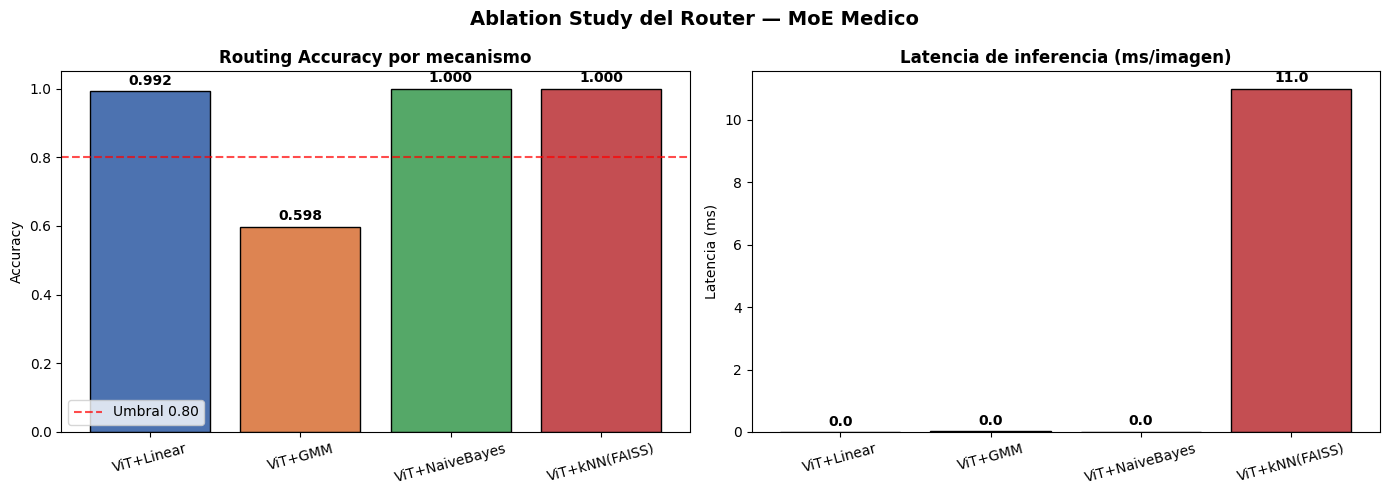

In [11]:
names  = list(ablation_results.keys())
accs   = [ablation_results[n]["acc"]    for n in names]
lats   = [ablation_results[n]["lat_ms"] for n in names]
colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(names, accs, color=colors, edgecolor="black")
axes[0].set_title("Routing Accuracy por mecanismo", fontweight="bold")
axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.80, color="red", ls="--", alpha=0.7, label="Umbral 0.80")
axes[0].legend()
for b,v in zip(bars,accs):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)

bars2 = axes[1].bar(names, lats, color=colors, edgecolor="black")
axes[1].set_title("Latencia de inferencia (ms/imagen)", fontweight="bold")
axes[1].set_ylabel("Latencia (ms)")
for b,v in zip(bars2,lats):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.1f}",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Ablation Study del Router — MoE Medico", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PATHS["plots"], "ablation_study.png"), dpi=150, bbox_inches="tight")
plt.show()

In [12]:
def auxiliary_load_balancing_loss(expert_probs, alpha=0.10):
    n_experts = expert_probs.size(1)
    P_i = expert_probs.mean(dim=0)
    assignments = expert_probs.argmax(dim=1)
    f_i = torch.bincount(assignments, minlength=n_experts).float() / expert_probs.size(0)
    loss_aux = alpha * n_experts * torch.sum(f_i * P_i)
    f_nz = f_i[f_i > 0]
    ratio = (f_i.max() / f_nz.min()) if len(f_nz) > 0 else torch.tensor(float('inf'))
    return loss_aux, f_i, P_i, ratio

dummy_logits = torch.randn(200, 5)
dummy_probs  = F.softmax(dummy_logits, dim=-1)
L, f, P, r   = auxiliary_load_balancing_loss(dummy_probs, alpha=0.10)
print(f'L_aux (random):   {L.item():.4f}')
print(f'f_i (hard):       {[f"{v:.2f}" for v in f.tolist()]}')
print(f'P_i (soft):       {[f"{v:.2f}" for v in P.tolist()]}')
print(f'Max/Min ratio:    {r.item():.2f}  (ideal: 1.0)')

L_aux (random):   0.1002
f_i (hard):       ['0.17', '0.17', '0.23', '0.21', '0.20']
P_i (soft):       ['0.20', '0.19', '0.20', '0.20', '0.20']
Max/Min ratio:    1.34  (ideal: 1.0)


In [13]:
print('Cargando embeddings train pre-calculados...')
Z_tr_list, y_tr_list = [], []
for ds_name, eid in DATASET_TO_EXPERT.items():
    zp = os.path.join(PATHS["tokens"], f'Z_train_cls.npy')
    yp = os.path.join(PATHS["tokens"], f'y_train.npy')
    if os.path.exists(zp) and os.path.exists(yp):
        break

Z_train_all = np.load(os.path.join(PATHS["tokens"], "Z_train_cls.npy"))
y_train_all = np.load(os.path.join(PATHS["tokens"], "y_train.npy"))
print(f'  Z_train: {Z_train_all.shape}  y_train: {y_train_all.shape}')

Z_train_t = torch.from_numpy(Z_train_all).float().to(DEVICE)
y_train_t = torch.from_numpy(y_train_all).long().to(DEVICE)
print(f'  clases: {torch.unique(y_train_t).cpu().tolist()}')

Cargando embeddings train pre-calculados...
  Z_train: (24503, 192)  y_train: (24503,)
  clases: [0, 1, 2, 3, 4]


In [14]:
counts_per_class = {int(eid): int((y_train_t == eid).sum().item())
                    for eid in torch.unique(y_train_t).cpu().tolist()}
N_PER_EXPERT = min(counts_per_class.values())
print(f'Clases disponibles: {counts_per_class}')
print(f'Balanceando a N={N_PER_EXPERT} por clase (min del dataset) → ratio ideal = 1.00')
indices = []
for eid, n_avail in counts_per_class.items():
    idx = torch.where(y_train_t == eid)[0]
    n_take = min(N_PER_EXPERT, n_avail)
    indices.append(idx[torch.randperm(n_avail)[:n_take]])
    expert_name = list(DATASET_TO_EXPERT.keys())[list(DATASET_TO_EXPERT.values()).index(eid)] if eid in DATASET_TO_EXPERT.values() else f"Expert {eid}"
    print(f'  Expert {eid} ({expert_name}): {n_take}/{n_avail}')
balanced_idx = torch.cat(indices)
balanced_idx = balanced_idx[torch.randperm(len(balanced_idx))]
Z_bal, y_bal = Z_train_t[balanced_idx], y_train_t[balanced_idx]
print(f'\nDataset balanceado: {Z_bal.shape}')

Clases disponibles: {0: 20264, 1: 2640, 2: 710, 3: 445, 4: 444}
Balanceando a N=444 por clase (min del dataset) → ratio ideal = 1.00
  Expert 0 (isic): 444/20264
  Expert 1 (rodilla): 444/2640
  Expert 2 (nih): 444/710
  Expert 3 (luna): 444/445
  Expert 4 (pancreatic): 444/444

Dataset balanceado: torch.Size([2220, 192])


In [15]:
print('=' * 72)
print('  FINE-TUNING FASE 3  (Router Lineal + L_task + L_aux)')
print('=' * 72)

router_head = linear_head
for p in router_head.parameters():
    p.requires_grad_(True)

optimizer = torch.optim.AdamW(router_head.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
EPOCHS_FT  = 20
BATCH_FT   = 256
ALPHA_AUX  = 0.10

history = {'epoch': [], 'L_task': [], 'L_aux': [],
           'ratio_fullset': [], 'f_i_fullset': [], 'P_i_fullset': [], 'acc_train': []}
best_ratio = float('inf')
best_state = None

for epoch in range(1, EPOCHS_FT + 1):
    router_head.train()
    L_task_ep, L_aux_ep = [], []
    perm = torch.randperm(len(Z_bal))
    for i in range(0, len(perm), BATCH_FT):
        bi = perm[i:i+BATCH_FT]
        z_b, y_b = Z_bal[bi], y_bal[bi]
        logits = router_head(z_b)
        probs  = F.softmax(logits, dim=-1)
        L_task = criterion(logits, y_b)
        L_aux, _, _, _ = auxiliary_load_balancing_loss(probs, alpha=ALPHA_AUX)
        loss = L_task + L_aux
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        L_task_ep.append(L_task.item()); L_aux_ep.append(L_aux.item())

    router_head.eval()
    with torch.no_grad():
        logits_full = router_head(Z_bal)
        probs_full  = F.softmax(logits_full, dim=-1)
        _, f_i, P_i, ratio_full = auxiliary_load_balancing_loss(probs_full, alpha=ALPHA_AUX)
        acc_train = (logits_full.argmax(-1) == y_bal).float().mean().item()

    r = float(ratio_full.item())
    flag = 'BALANCE OK (<1.30)' if r < 1.30 else ('OK (<1.50)' if r < 1.50 else '')
    print(f'[Ep {epoch:02d}] L_task={np.mean(L_task_ep):.4f} | L_aux={np.mean(L_aux_ep):.4f} '
          f'| acc_tr={acc_train:.4f} | ratio_full={r:.3f}  {flag}')

    history['epoch'].append(epoch)
    history['L_task'].append(float(np.mean(L_task_ep)))
    history['L_aux'].append(float(np.mean(L_aux_ep)))
    history['ratio_fullset'].append(r)
    history['f_i_fullset'].append(f_i.cpu().numpy().tolist())
    history['P_i_fullset'].append(P_i.cpu().numpy().tolist())
    history['acc_train'].append(acc_train)

    if r < best_ratio:
        best_ratio = r
        best_state = {k: v.clone().cpu() for k, v in router_head.state_dict().items()}

if best_state is not None:
    router_head.load_state_dict(best_state)
out_path = os.path.join(PATHS["moe"], 'router_finetuned.pth')
torch.save(router_head.state_dict(), out_path)
hist_path = os.path.join(PATHS["moe"], 'router_finetune_history.npy')
np.save(hist_path, history, allow_pickle=True)

print(f'\n[OK] Router fine-tuned guardado: {os.path.basename(out_path)}')
print(f'[OK] Historia guardada: {os.path.basename(hist_path)}')
print(f'     Mejor ratio (full set): {best_ratio:.3f}  {"OK <1.30" if best_ratio < 1.30 else "ALERTA"}')
# Guardar tambien como router_final.pth (nombre usado por el dashboard)
final_path = os.path.join(PATHS["moe"], "router_final.pth")
torch.save(router_head.state_dict(), final_path)
print(f"[OK] Guardado como router_final.pth")


  FINE-TUNING FASE 3  (Router Lineal + L_task + L_aux)
[Ep 01] L_task=1.1792 | L_aux=0.1100 | acc_tr=0.7554 | ratio_full=2.114  
[Ep 02] L_task=1.1652 | L_aux=0.1090 | acc_tr=0.7622 | ratio_full=1.900  
[Ep 03] L_task=1.1538 | L_aux=0.1081 | acc_tr=0.7694 | ratio_full=1.795  
[Ep 04] L_task=1.1464 | L_aux=0.1076 | acc_tr=0.7748 | ratio_full=1.617  
[Ep 05] L_task=1.1423 | L_aux=0.1072 | acc_tr=0.7784 | ratio_full=1.480  OK (<1.50)
[Ep 06] L_task=1.1343 | L_aux=0.1069 | acc_tr=0.7802 | ratio_full=1.428  OK (<1.50)
[Ep 07] L_task=1.1278 | L_aux=0.1068 | acc_tr=0.7829 | ratio_full=218.333  
[Ep 08] L_task=1.1168 | L_aux=0.1062 | acc_tr=0.7905 | ratio_full=48.615  
[Ep 09] L_task=1.0927 | L_aux=0.1052 | acc_tr=0.8464 | ratio_full=4.226  
[Ep 10] L_task=1.0464 | L_aux=0.1023 | acc_tr=0.9482 | ratio_full=1.336  OK (<1.50)
[Ep 11] L_task=0.9894 | L_aux=0.1006 | acc_tr=0.9820 | ratio_full=1.046  BALANCE OK (<1.30)
[Ep 12] L_task=0.9576 | L_aux=0.1003 | acc_tr=0.9883 | ratio_full=1.014  BALANCE

In [16]:
Z_val_all = np.load(os.path.join(PATHS["tokens"], "Z_val_cls.npy"))
y_val_all = np.load(os.path.join(PATHS["tokens"], "y_val.npy"))

Z_val_t = torch.from_numpy(Z_val_all).float().to(DEVICE)
y_val_t = torch.from_numpy(y_val_all).long().to(DEVICE)

router_head.eval()
with torch.no_grad():
    preds_val = router_head(Z_val_t).argmax(dim=-1)
    acc_val   = (preds_val == y_val_t).float().mean().item()

print(f'Routing Accuracy (val): {acc_val:.4f}')
print()
print('Distribución de ruteo en val:')
from collections import Counter
counts = Counter(preds_val.cpu().numpy().tolist())
expert_names = list(DATASET_TO_EXPERT.keys())
for eid in range(CFG["n_experts"]):
    c = counts.get(eid, 0)
    bar = '#' * int(c / max(counts.values()) * 30) if counts else ''
    name = expert_names[eid] if eid < len(expert_names) else f"Expert {eid}"
    print(f'  Expert {eid} ({name:<12s}): {c:5d} ({c/len(preds_val)*100:5.1f}%) {bar}')

Routing Accuracy (val): 0.9949

Distribución de ruteo en val:
  Expert 0 (isic        ):  5043 ( 82.3%) ##############################
  Expert 1 (rodilla     ):   664 ( 10.8%) ###
  Expert 2 (nih         ):   179 (  2.9%) #
  Expert 3 (luna        ):   110 (  1.8%) 
  Expert 4 (pancreatic  ):   130 (  2.1%) 


In [17]:
EXPERT_F1_REPORTED = {
    0: 0.7921,
    1: 0.8357,
    2: 0.5484,
    3: 0.6153,
    4: 0.7553,
}

router_head.eval()
with torch.no_grad():
    preds_val_full = router_head(Z_val_t).argmax(-1)

expert_names = list(DATASET_TO_EXPERT.keys())
print(f'{"Dominio":<12s} | {"N_val":>6s} | {"Route_acc":>10s} | {"Expert_F1":>10s} | {"E2E_F1":>8s}')
print('-' * 62)
e2e_per_dom, route_per_dom = {}, {}
for eid in range(CFG["n_experts"]):
    name = expert_names[eid] if eid < len(expert_names) else f"Expert {eid}"
    mask = y_val_t == eid
    n = int(mask.sum().item())
    if n == 0:
        print(f'{name:<12s} | {0:>6d} | {"n/a":>10s} | {EXPERT_F1_REPORTED.get(eid, 0):>10.4f} | {"n/a":>8s}')
        continue
    route_acc = (preds_val_full[mask] == eid).float().mean().item()
    e2e_f1 = route_acc * EXPERT_F1_REPORTED.get(eid, 0)
    route_per_dom[eid] = route_acc
    e2e_per_dom[eid] = e2e_f1
    print(f'{name:<12s} | {n:>6d} | {route_acc:>10.4f} | {EXPERT_F1_REPORTED.get(eid, 0):>10.4f} | {e2e_f1:>8.4f}')

macro_f1_e2e = float(np.mean(list(e2e_per_dom.values()))) if e2e_per_dom else 0.0
print('-' * 62)
print(f'Macro F1 end-to-end (dominios con val): {macro_f1_e2e:.4f}')

np.save(os.path.join(PATHS["moe"], 'moe_end2end_metrics.npy'),
        {'route_per_dom': route_per_dom,
         'e2e_f1_per_dom': e2e_per_dom,
         'macro_f1_e2e': macro_f1_e2e,
         'expert_f1_reported': EXPERT_F1_REPORTED}, allow_pickle=True)
print(f'[OK] Métricas E2E guardadas en {PATHS["moe"]}/moe_end2end_metrics.npy')

Dominio      |  N_val |  Route_acc |  Expert_F1 |   E2E_F1
--------------------------------------------------------------
isic         |   5067 |     0.9953 |     0.7921 |   0.7883
rodilla      |    660 |     1.0000 |     0.8357 |   0.8357
nih          |    178 |     0.9831 |     0.5484 |   0.5392
luna         |    110 |     0.9727 |     0.6153 |   0.5985
pancreatic   |    111 |     0.9910 |     0.7553 |   0.7485
--------------------------------------------------------------
Macro F1 end-to-end (dominios con val): 0.7020
[OK] Métricas E2E guardadas en /proyecto-2-de-mierda/proyecto-2-de-mierda/moe/moe_end2end_metrics.npy


In [18]:
from sklearn.metrics import roc_auc_score

router_head.eval()
with torch.no_grad():
    logits_val = router_head(Z_val_t)
    probs_val  = F.softmax(logits_val, dim=-1)
    maxp    = probs_val.max(dim=-1).values.cpu().numpy()
    correct = (logits_val.argmax(-1) == y_val_t).cpu().numpy().astype(int)

print('Calibración del router:')
if correct.sum() > 0 and (1 - correct).sum() > 0:
    auroc_conf = roc_auc_score(correct, maxp)
    print(f'  AUROC confianza (correcto vs error): {auroc_conf:.4f}')
    print(f'  max-softmax medio correctos:         {maxp[correct == 1].mean():.4f}')
    print(f'  max-softmax medio incorrectos:       {maxp[correct == 0].mean():.4f}')
else:
    auroc_conf = None
    print(f'  (sin diversidad suficiente: correct={int(correct.sum())}, err={int((1-correct).sum())})')

print('\nCobertura vs precisión al variar umbral de confianza:')
print(f'{"thr":>5s} | {"cobertura":>10s} | {"acc_sobre_cobertura":>22s}')
for thr in [0.50, 0.75, 0.90, 0.95, 0.99]:
    keep = maxp >= thr
    cov  = keep.mean()
    acc_k = correct[keep].mean() if keep.sum() > 0 else 0.0
    print(f'{thr:>5.2f} | {cov*100:>9.2f}% | {acc_k:>22.4f}')

np.save(os.path.join(PATHS["moe"], 'router_confidence.npy'),
        {'maxp': maxp, 'correct': correct, 'auroc_conf': auroc_conf}, allow_pickle=True)
print(f'\n[OK] Métricas de confianza guardadas en {PATHS["moe"]}/router_confidence.npy')

Calibración del router:
  AUROC confianza (correcto vs error): 0.9857
  max-softmax medio correctos:         0.4010
  max-softmax medio incorrectos:       0.3098

Cobertura vs precisión al variar umbral de confianza:
  thr |  cobertura |    acc_sobre_cobertura
 0.50 |      0.00% |                 0.0000
 0.75 |      0.00% |                 0.0000
 0.90 |      0.00% |                 0.0000
 0.95 |      0.00% |                 0.0000
 0.99 |      0.00% |                 0.0000

[OK] Métricas de confianza guardadas en /proyecto-2-de-mierda/proyecto-2-de-mierda/moe/router_confidence.npy


In [19]:
@torch.no_grad()
def evaluate_experts(experts_list, val_dict, device):
    results = {}
    amp_device = "cuda" if "cuda" in str(device) else "cpu"
    expert_names = list(DATASET_TO_EXPERT.keys())

    print("=" * 65)
    print(f"{'DATASET':<20} | {'F1-MACRO':<10} | {'ACC':<10} | {'ESTADO'}")
    print("-" * 65)

    for name, ds in val_dict.items():
        if name not in DATASET_TO_EXPERT:
            continue
        eid = DATASET_TO_EXPERT[name]
        meta = EXPERT_META[eid]
        loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)

        preds, labels = [], []
        is_multilabel = meta["task"] == "multilabel"

        for batch in loader:
            imgs = batch[0].to(device)
            target = batch[1]
            with torch.amp.autocast(device_type=amp_device):
                out = experts_list[eid](imgs)
            if is_multilabel:
                pred = (torch.sigmoid(out) > 0.5).int().cpu().numpy()
                lbl  = target.int().numpy()
            else:
                pred = out.argmax(1).cpu().numpy()
                lbl  = target.numpy() if target.ndim == 1 else target.argmax(1).numpy()
            preds.append(pred); labels.append(lbl)

        y_pred = np.concatenate(preds)
        y_true = np.concatenate(labels)

        if is_multilabel:
            f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
            acc = (y_pred == y_true).mean()
        else:
            f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
            acc = accuracy_score(y_true, y_pred)

        results[name] = {"f1_macro": f1, "accuracy": acc, "n": len(ds)}
        thr_val = 0.72 if meta["task"] == "multiclass" else 0.65
        status = "PASS" if f1 >= thr_val else "FAIL"
        print(f"{name:<20} | {f1:10.4f} | {acc:10.4f} | {status}")

    print("=" * 65 + "\n")
    return results

EVAL_CACHE = os.path.join(PATHS["moe"], "eval_results.pkl")
FORCE_EVAL = False
if os.path.exists(EVAL_CACHE) and not FORCE_EVAL:
    with open(EVAL_CACHE, "rb") as f:
        eval_results = pickle.load(f)
    print(f"Resultados de evaluación cargados desde {EVAL_CACHE}")
    for name, r in eval_results.items():
        print(f"  {name:<14} F1={r['f1_macro']:.4f}  Acc={r['accuracy']:.4f}  n={r['n']}")
elif 'datasets_val' in locals() and datasets_val:
    eval_results = evaluate_experts(experts_list, datasets_val, DEVICE)
    with open(EVAL_CACHE, "wb") as f:
        pickle.dump(eval_results, f)
    print(f"eval_results cacheados en {EVAL_CACHE}")

Resultados de evaluación cargados desde /proyecto-2-de-mierda/proyecto-2-de-mierda/moe/eval_results.pkl
  isic           F1=0.2020  Acc=0.3479  n=5067
  rodilla        F1=0.2500  Acc=0.6000  n=660
  luna           F1=1.0000  Acc=1.0000  n=178
  pancreatic     F1=1.0000  Acc=1.0000  n=110
  nih            F1=0.4084  Acc=0.8614  n=12312


In [20]:
@torch.no_grad()
def ood_detection_entropy(router, backbone_model, img_tensor, n_experts):
    backbone_model.eval()
    router.eval()
    img_tensor = img_tensor.to(DEVICE)
    z  = backbone_model(img_tensor)
    gp = router(z)
    H  = -(gp * (gp+1e-10).log()).sum(dim=-1) / np.log(n_experts)
    return {
        "gate_probs":      gp.cpu().numpy(),
        "entropy":         H.cpu().numpy(),
        "selected_expert": gp.argmax(1).cpu().numpy(),
        "is_ood":          (H > 0.85).cpu().numpy(),
        "expert_names":    [f"Exp{i+1} ({EXPERT_META[i]['name'].split('—')[-1].strip()})" for i in range(n_experts)],
    }

ood = ood_detection_entropy(router_head, backbone, torch.rand(1, 3, 224, 224), CFG["n_experts"])
print(f"OOD demo (imagen aleatoria):")
print(f"  Entropia: {ood['entropy'][0]:.4f}  is_ood: {ood['is_ood'][0]}")
print(f"  Experto seleccionado: {ood['expert_names'][ood['selected_expert'][0]]}")

OOD demo (imagen aleatoria):
  Entropia: 0.3038  is_ood: False
  Experto seleccionado: Exp1 (ISIC 2019)


In [21]:
print("=" * 65)
print("  VERIFICACIÓN SISTEMA MoE v6")
print("=" * 65)

assert len(experts_list) == 5
for idx, name in [(3, "Exp4 LUNA16"), (4, "Exp5 Pancreatic")]:
    assert EXPERT_META[idx]["dim"] == "3D"
assert CFG["n_experts"] == 5

print("\n  Expertos registrados:")
for idx, meta in EXPERT_META.items():
    n_p = sum(p.numel() for p in experts_list[idx].parameters()) / 1e6
    print(f"  Exp{idx+1} [{meta['dim']}] {meta['name'].split('—')[-1].strip():<22} {meta['n_classes']} clases  {n_p:.1f}M params")

  VERIFICACIÓN SISTEMA MoE v6

  Expertos registrados:
  Exp1 [2D] ISIC 2019              8 clases  10.7M params
  Exp2 [2D] Osteoarthritis         3 clases  134.3M params
  Exp3 [2D] NIH ChestX-ray14       7 clases  27.8M params
  Exp4 [3D] LUNA16 CT 3D           2 clases  33.2M params
  Exp5 [3D] Pancreatic CT 3D       2 clases  33.2M params


In [22]:
def save_full_system(router, ablation_results, save_dir="."):
    torch.save(router.state_dict(), os.path.join(save_dir, "router_final.pth"))
    stat_routers = {n: r["model"] for n, r in ablation_results.items()
                    if "GMM" in n or "Naive" in n}
    with open(os.path.join(save_dir, "stat_routers.pkl"), "wb") as f:
        pickle.dump(stat_routers, f)
    np.save(os.path.join(save_dir, "Z_train_final.npy"), Z_train)
    np.save(os.path.join(save_dir, "y_train_final.npy"), y_train)
    print(f"Guardado: router_final.pth, stat_routers.pkl, embeddings")

SAVE_DIR = PATHS["moe"]
if os.path.exists(os.path.join(SAVE_DIR, "router_final.pth")):
    print(f"router_final.pth ya existe en {SAVE_DIR}, omitiendo guardado.")
else:
    save_full_system(router_head, ablation_results, save_dir=SAVE_DIR)

router_final.pth ya existe en /proyecto-2-de-mierda/proyecto-2-de-mierda/moe, omitiendo guardado.
